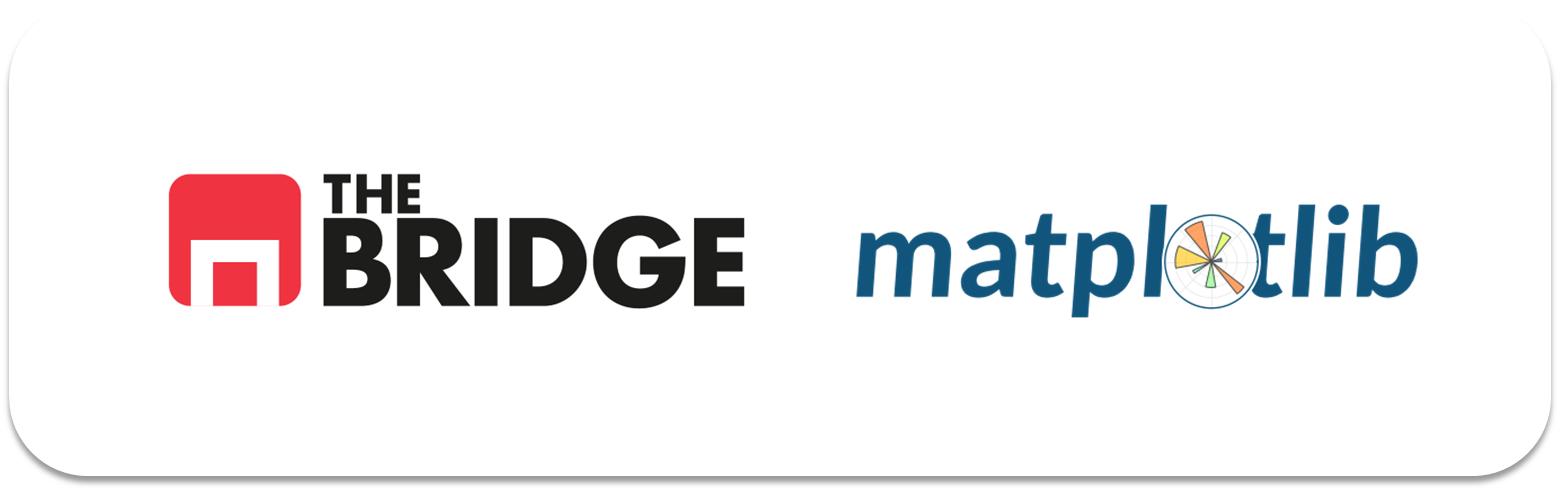

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [10]:
# Carga del dataset
df_cities = pd.read_csv("./data/california_cities.csv")

# Mostrar parte del contenido
df_cities.head()
df_cities.info()

# Eliminar filas con valores nulos
df_cities = df_cities.dropna()
df_cities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 42

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center"). (Colores: azul, gris, aceituna, marrón, con trasparencia)  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Bradley Hand ITC", tamaño 18, color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion.
4. El boxplot de la altura de las ciudades.

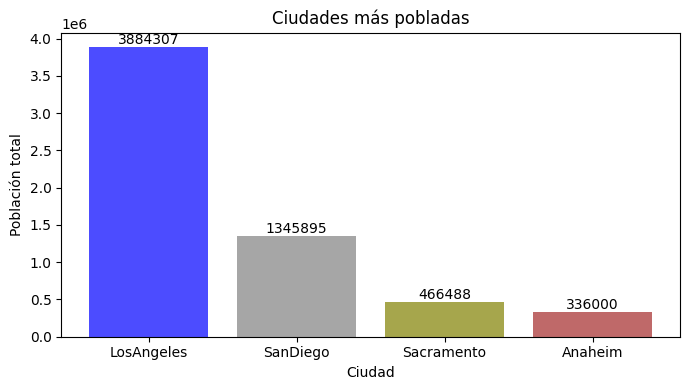

In [ ]:
top_cities = df_cities.nlargest(4, "population_total").copy()

colors = ["blue", "gray", "olive", "brown"]

plt.figure(figsize=(7,4))
plt.bar(top_cities["city"], top_cities["population_total"], color=colors, alpha=0.7)


for i, value in enumerate(top_cities["population_total"]):
    plt.text(i, value, str(int(value)), ha="center", va="bottom")

plt.title("Ciudades más pobladas")
plt.xlabel("Ciudad")
plt.ylabel("Población total")
plt.tight_layout()
plt.show()

findfont: Font family 'Bradley Hand ITC' not found.
findfont: Font family 'Bradley Hand ITC' not found.
findfont: Font family 'Bradley Hand ITC' not found.
findfont: Font family 'Bradley Hand ITC' not found.
findfont: Font family 'Bradley Hand ITC' not found.


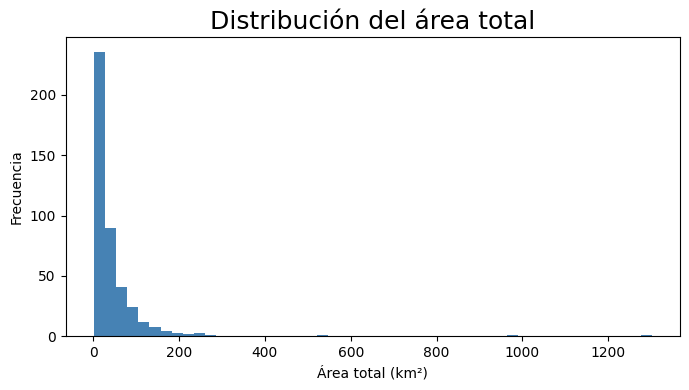

In [13]:
plt.figure(figsize=(7,4))
plt.hist(df_cities["area_total_km2"], bins=50, color="steelblue")

plt.title("Distribución del área total",
          fontname="Bradley Hand ITC", fontsize=18)

plt.xlabel("Área total (km²)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

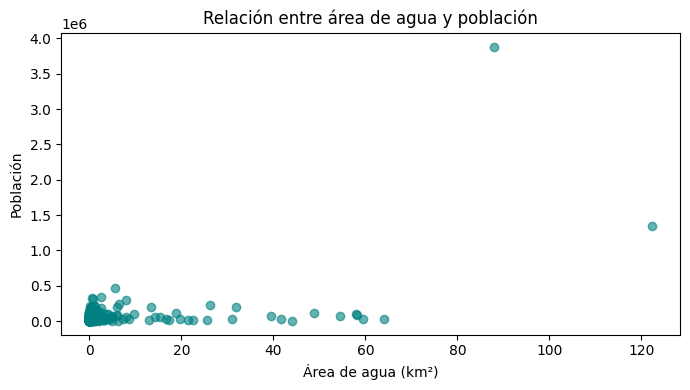

In [15]:
plt.figure(figsize=(7,4))

plt.scatter(df_cities["area_water_km2"],
            df_cities["population_total"],
            alpha=0.6,
            color="teal")

plt.title("Relación entre área de agua y población")
plt.xlabel("Área de agua (km²)")
plt.ylabel("Población")
plt.tight_layout()
plt.show()


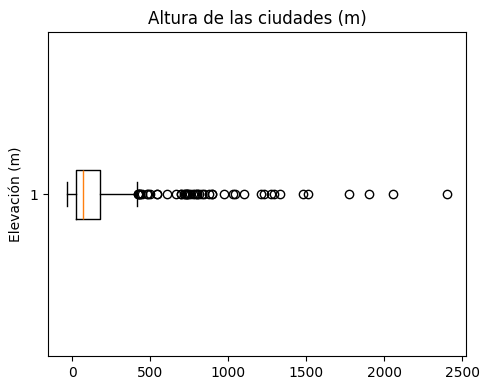

In [18]:
plt.figure(figsize=(5,4))
plt.boxplot(df_cities["elevation_m"], vert=False)

plt.title("Altura de las ciudades (m)")
plt.ylabel("Elevación (m)")
plt.tight_layout()
plt.show()

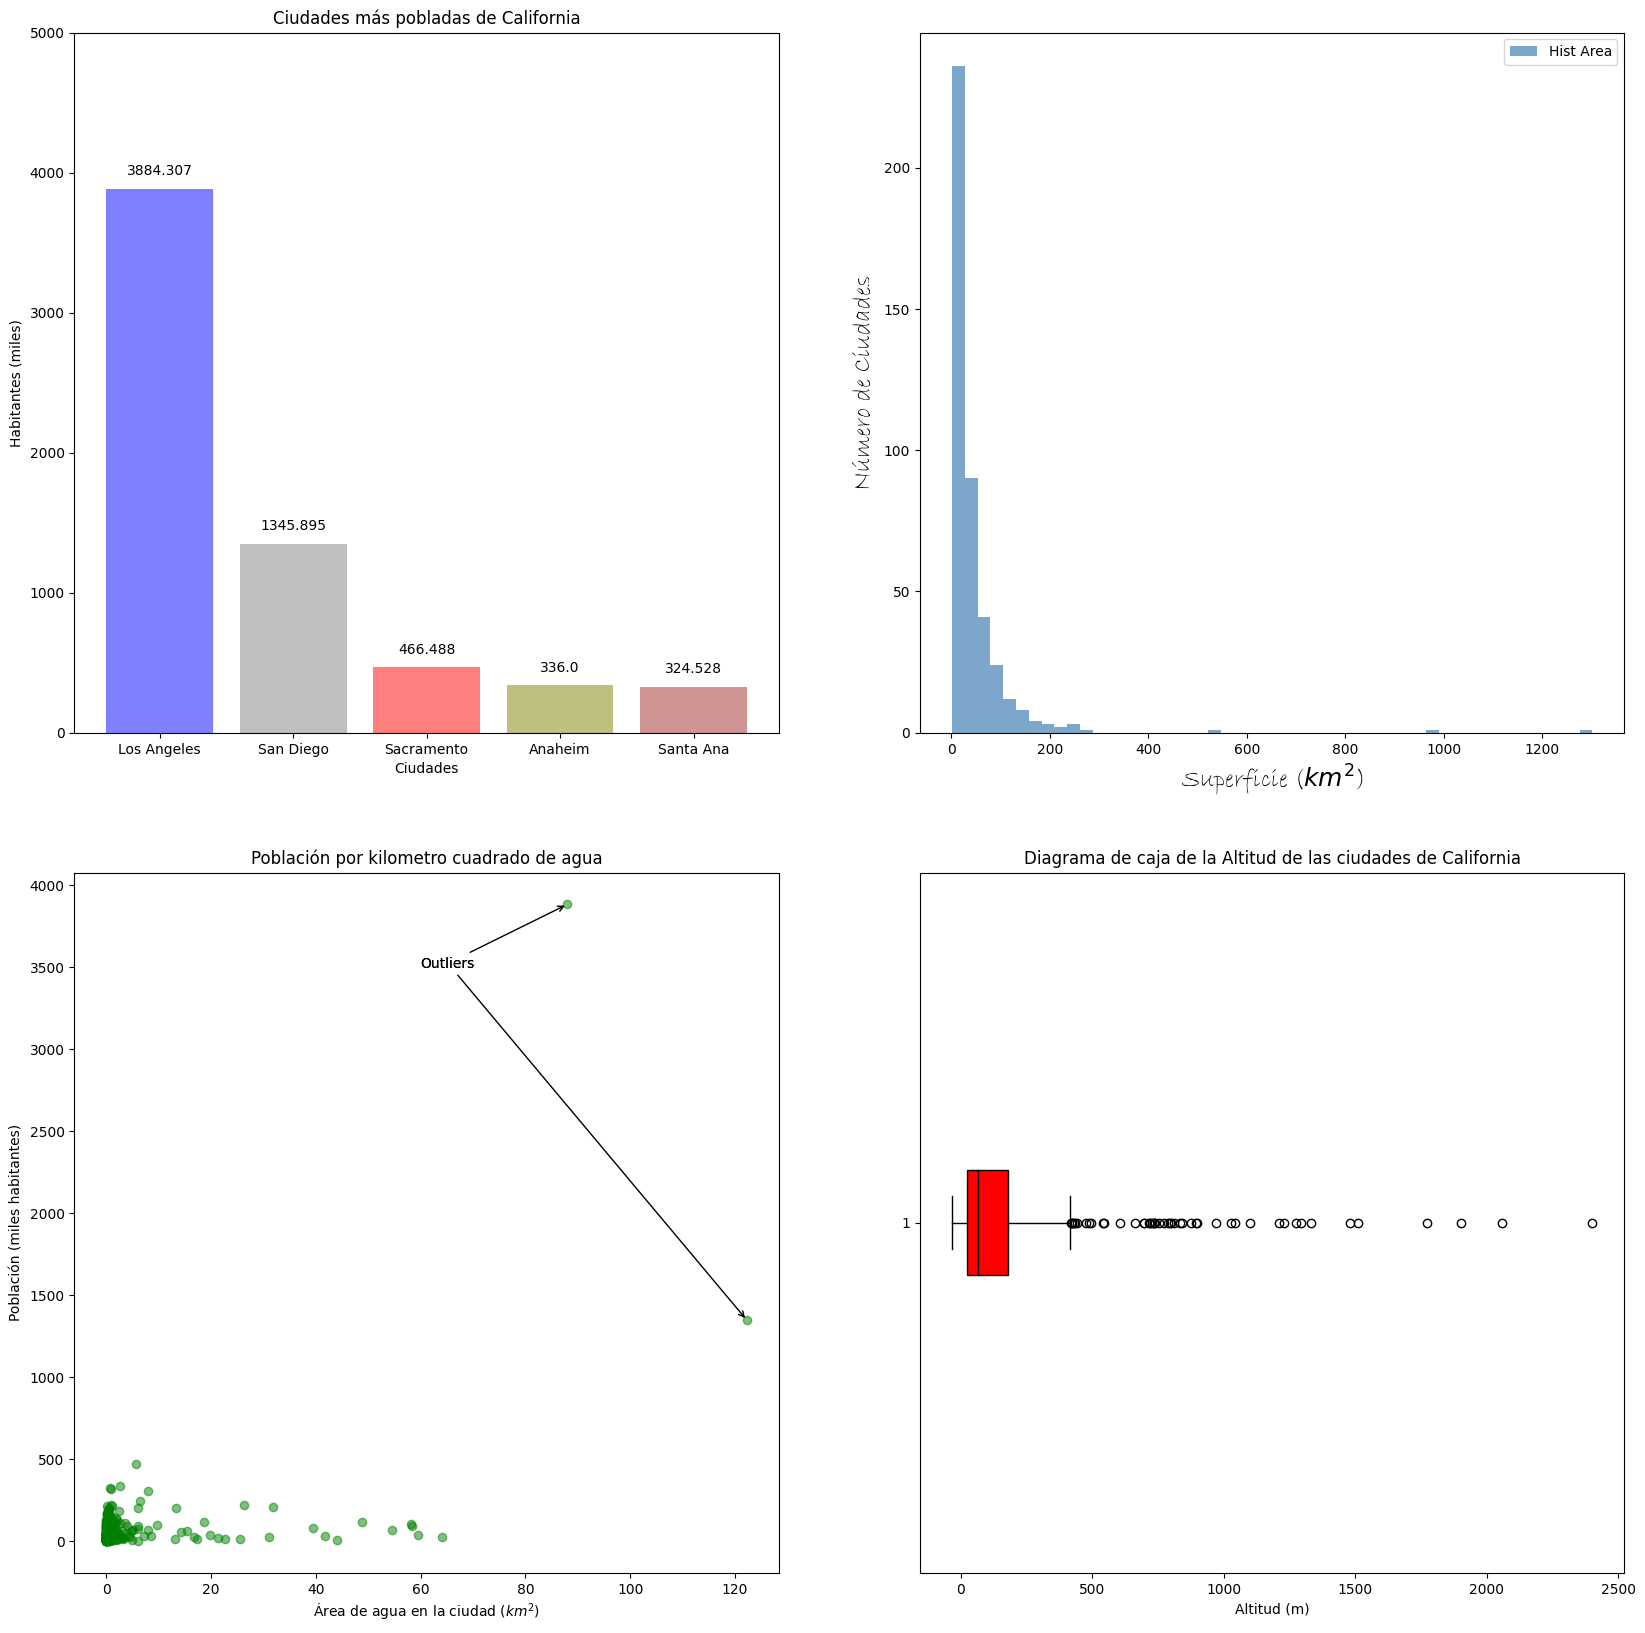

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

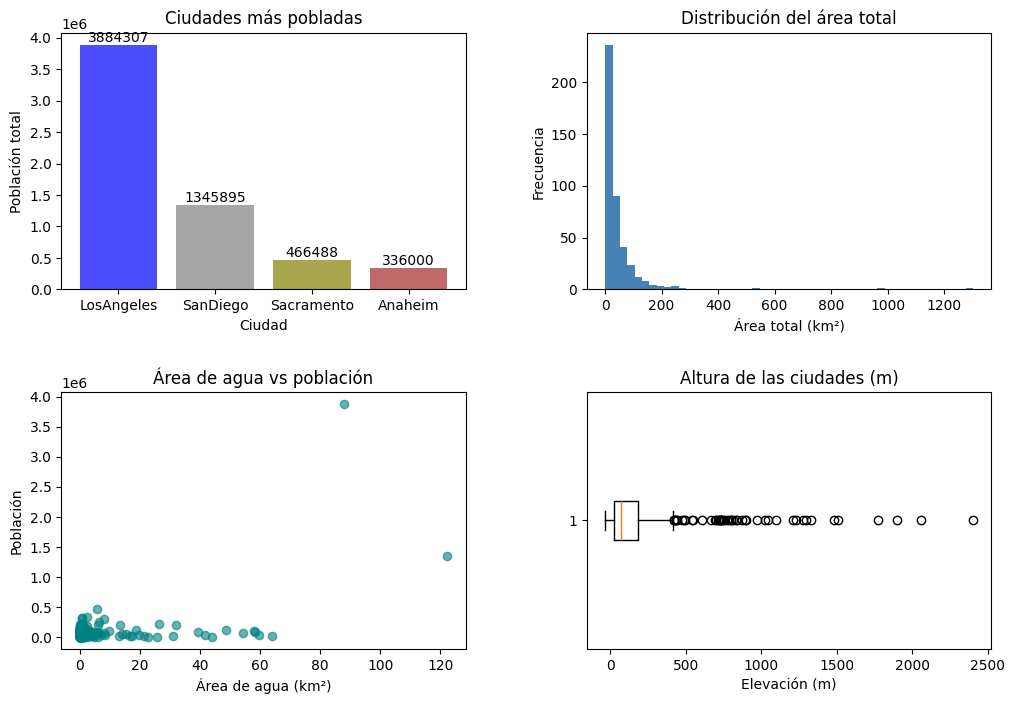

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(12,8))
fig.subplots_adjust(hspace=0.4, wspace=0.3)


# 1. Ciudades más pobladas

top_cities = df_cities.nlargest(4, "population_total").copy()
colors = ["blue", "gray", "olive", "brown"]

ax[0,0].bar(top_cities["city"], top_cities["population_total"], color=colors, alpha=0.7)

for i, value in enumerate(top_cities["population_total"]):
    ax[0,0].text(i, value, str(int(value)), ha="center", va="bottom")

ax[0,0].set_title("Ciudades más pobladas")
ax[0,0].set_xlabel("Ciudad")
ax[0,0].set_ylabel("Población total")


# 2. Histograma del área total ocupada

ax[0,1].hist(df_cities["area_total_km2"], bins=50, color="steelblue")
ax[0,1].set_title("Distribución del área total")
ax[0,1].set_xlabel("Área total (km²)")
ax[0,1].set_ylabel("Frecuencia")



# 3. Scatter área de agua vs población

ax[1,0].scatter(df_cities["area_water_km2"],
                df_cities["population_total"],
                alpha=0.6, color="teal")

ax[1,0].set_title("Área de agua vs población")
ax[1,0].set_xlabel("Área de agua (km²)")
ax[1,0].set_ylabel("Población")



# 4. Boxplot horizontal de elevación

ax[1,1].boxplot(df_cities["elevation_m"], vert=False)
ax[1,1].set_title("Altura de las ciudades (m)")
ax[1,1].set_xlabel("Elevación (m)")


# Mostrar la figura

plt.show()


# Guardar la figura en PNG

fig.savefig("california_visualization.png", dpi=300, bbox_inches="tight")